# Heart Disease Prediction using PySpark MLlib
- Dataset: Heart Disease Dataset
- Dataset Source: https://www.kaggle.com/datasets/hosammhmdali/heart-disease-dataset

---

## 1. Import Libraries/Dataset

### 1.a Download the Dataset
### 1.b Import the Required Libraries

In [1]:
# Install PySpark in Google Colab
!pip install pyspark --quiet

In [2]:
# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, isnan, when, desc, avg, stddev, corr, rand
from pyspark.sql.types import DoubleType, IntegerType


# Import MLlib libraries for preprocessing
from pyspark.ml.feature import VectorAssembler, StandardScaler, MinMaxScaler
from pyspark.ml.stat import Correlation

# Import MLlib classification algorithms
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier

# Import evaluation metrics
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Import for confusion matrix
from pyspark.mllib.evaluation import MulticlassMetrics

# Import for visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set display options
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [3]:
# Create Spark Session
spark = SparkSession.builder \
    .appName("Heart Disease Prediction") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark Version:", spark.version)
print("✓ Spark Session Created Successfully!")

Spark Version: 4.0.1
✓ Spark Session Created Successfully!


In [4]:
# Load the dataset
# Note: Upload your 'Dataset Heart Disease.csv' file to Colab first
# You can upload it using the file upload feature in Colab

# For Colab, you might need to upload the file first
from google.colab import files
uploaded = files.upload()

# Read CSV file into Spark DataFrame
df = spark.read.csv('Dataset Heart Disease.csv', header=True, inferSchema=True)

print("✓ Dataset loaded successfully!")
print(f"Number of rows: {df.count()}")
print(f"Number of columns: {len(df.columns)}")

Saving Dataset Heart Disease.csv to Dataset Heart Disease (7).csv
✓ Dataset loaded successfully!
Number of rows: 1048
Number of columns: 13


---
## 2. Data Visualization and Exploration

### 2.a Print at least 5 rows for sanity check

In [5]:
# Display first 5 rows
print("First 5 rows of the dataset:")
df.show(5, truncate=False)

First 5 rows of the dataset:
+---+---+---+---------------+-----------+-----------+-------------------+-----------+--------------+---------------+-------+--------+------+
|_c0|age|sex|chest pain type|resting bps|cholesterol|fasting blood sugar|resting ecg|max heart rate|exercise angina|oldpeak|ST slope|target|
+---+---+---+---------------+-----------+-----------+-------------------+-----------+--------------+---------------+-------+--------+------+
|0  |40 |1  |2              |140        |289.0      |0                  |0          |172           |0              |0.0    |1       |0     |
|1  |49 |0  |3              |160        |180.0      |0                  |0          |156           |0              |1.0    |2       |1     |
|2  |37 |1  |2              |130        |283.0      |0                  |1          |98            |0              |0.0    |1       |0     |
|3  |48 |0  |4              |138        |214.0      |0                  |0          |108           |1              |1.5    |2

In [6]:
# Display last 5 rows
print("Last 5 rows of the dataset:")
df.orderBy(df.columns[0], ascending=False).show(5, truncate=False)


Last 5 rows of the dataset:
+----+---+---+---------------+-----------+-----------+-------------------+-----------+--------------+---------------+-------+--------+------+
|_c0 |age|sex|chest pain type|resting bps|cholesterol|fasting blood sugar|resting ecg|max heart rate|exercise angina|oldpeak|ST slope|target|
+----+---+---+---------------+-----------+-----------+-------------------+-----------+--------------+---------------+-------+--------+------+
|1189|38 |1  |3              |138        |175.0      |0                  |0          |173           |0              |0.0    |1       |0     |
|1188|57 |0  |2              |130        |236.0      |0                  |2          |174           |0              |0.0    |2       |1     |
|1187|57 |1  |4              |130        |131.0      |0                  |0          |115           |1              |1.2    |2       |1     |
|1186|68 |1  |4              |144        |193.0      |1                  |0          |141           |0              |3.4

In [7]:
# Display random sample of 10 rows
print("Random sample of 10 rows:")
df.orderBy(rand()).limit(10).show(truncate=False)


Random sample of 10 rows:
+---+---+---+---------------+-----------+-----------+-------------------+-----------+--------------+---------------+-------+--------+------+
|_c0|age|sex|chest pain type|resting bps|cholesterol|fasting blood sugar|resting ecg|max heart rate|exercise angina|oldpeak|ST slope|target|
+---+---+---+---------------+-----------+-----------+-------------------+-----------+--------------+---------------+-------+--------+------+
|168|54 |1  |3              |150        |232.0      |0                  |0          |165           |0              |1.6    |2       |1     |
|581|51 |1  |4              |131        |152.0      |1                  |2          |130           |1              |1.0    |2       |1     |
|49 |41 |1  |4              |110        |289.0      |0                  |0          |170           |0              |0.0    |2       |1     |
|293|53 |1  |4              |130        |182.0      |0                  |0          |148           |0              |0.0    |1   

### 2.b Print the description and shape of the dataset

In [8]:
# Print schema and data types
print("Dataset Schema:")
df.printSchema()

Dataset Schema:
root
 |-- _c0: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- sex: integer (nullable = true)
 |-- chest pain type: integer (nullable = true)
 |-- resting bps: integer (nullable = true)
 |-- cholesterol: double (nullable = true)
 |-- fasting blood sugar: integer (nullable = true)
 |-- resting ecg: integer (nullable = true)
 |-- max heart rate: integer (nullable = true)
 |-- exercise angina: integer (nullable = true)
 |-- oldpeak: double (nullable = true)
 |-- ST slope: integer (nullable = true)
 |-- target: integer (nullable = true)



In [9]:
# Print shape of dataset
num_rows = df.count()
num_cols = len(df.columns)
print(f"\nDataset Shape: ({num_rows}, {num_cols})")
print(f"Number of Rows: {num_rows}")
print(f"Number of Columns: {num_cols}")


Dataset Shape: (1048, 13)
Number of Rows: 1048
Number of Columns: 13


In [10]:
# Column names
print("\nColumn Names:")
print(df.columns)


Column Names:
['_c0', 'age', 'sex', 'chest pain type', 'resting bps', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'target']


In [11]:
# Statistical description of numerical features
print("Statistical Summary:")
df.describe().toPandas()


Statistical Summary:


,summary,_c0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,count,1048,1048,1048,1048,1048,1048,1048,1048,1048,1048,1048,1048,1048
1,mean,390.8416030534351,53.32538167938932,0.7347328244274809,2.8177480916030535,132.6135496183206,245.17270992366412,0.16221374045801526,0.6068702290076335,142.918893129771,0.3683206106870229,0.9423664122137411,1.532442748091603,0.4961832061068702
2,stddev,307.91663322144313,9.397821530540643,0.4416861470799055,1.118648849640703,17.367605002691988,57.101358794878195,0.3688227795494113,0.7633126257401192,24.42711525754087,0.48257927307256465,1.1004292517064356,0.6110233376591845,0.5002241453886705
3,min,0,28,0,1,92,85.0,0,0,69,0,-0.1,0,0
4,max,1189,77,1,4,200,603.0,1,2,202,1,6.2,3,1


### 2.c & 2.d Appropriate Visualization and Data Exploration

Let's explore the dataset and generate insights through various visualizations.

In [12]:
# Convert to Pandas for visualization (for smaller datasets)
df_pandas = df.toPandas()

print("Dataset converted to Pandas for visualization")
print(f"Shape: {df_pandas.shape}")

Dataset converted to Pandas for visualization
Shape: (1048, 13)


Target Variable Distribution:
+------+-----+
|target|count|
+------+-----+
|     1|  520|
|     0|  528|
+------+-----+



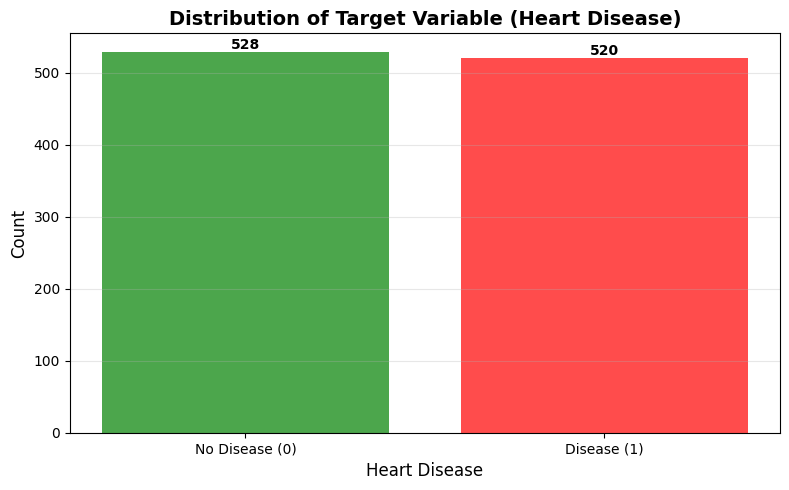


Class Balance: 528 without disease, 520 with disease


In [13]:
# Target variable distribution
print("Target Variable Distribution:")
df.groupBy('target').count().show()

# Visualize target distribution
plt.figure(figsize=(8, 5))
target_counts = df_pandas['target'].value_counts()
plt.bar(['No Disease (0)', 'Disease (1)'], target_counts.values, color=['green', 'red'], alpha=0.7)
plt.xlabel('Heart Disease', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Target Variable (Heart Disease)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nClass Balance: {target_counts[0]} without disease, {target_counts[1]} with disease")

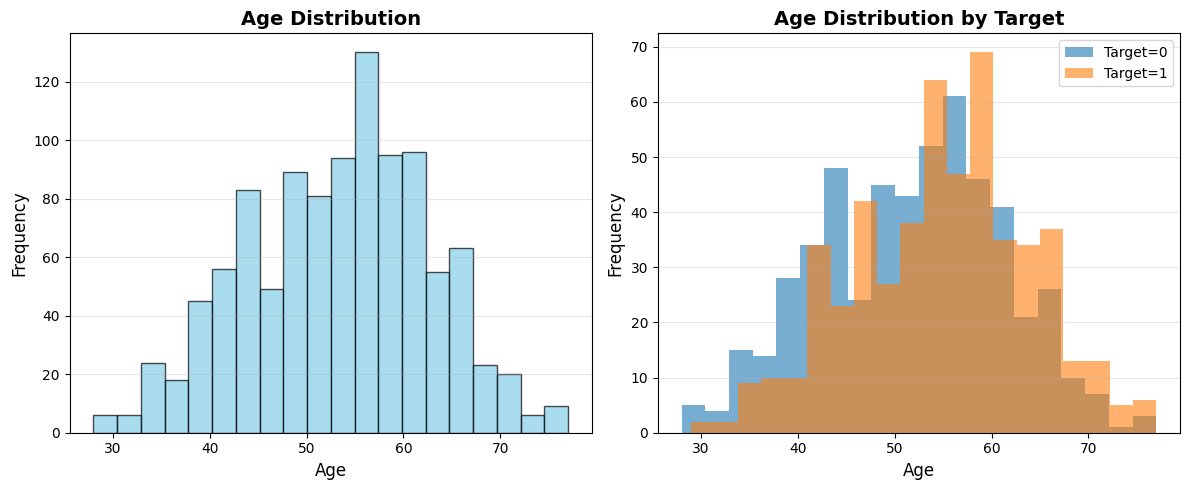

In [14]:
# Age distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_pandas['age'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
for target_val in [0, 1]:
    plt.hist(df_pandas[df_pandas['target'] == target_val]['age'],
             bins=20, alpha=0.6, label=f'Target={target_val}')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Age Distribution by Target', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Gender Distribution:
+---+-----+
|sex|count|
+---+-----+
|  1|  770|
|  0|  278|
+---+-----+



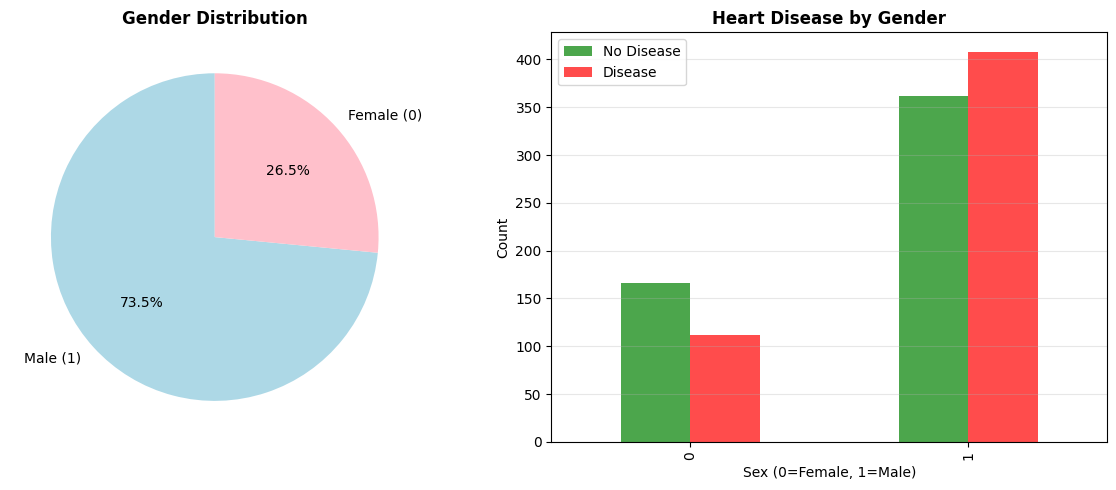

In [15]:
# Gender distribution analysis
print("Gender Distribution:")
df.groupBy('sex').count().show()

plt.figure(figsize=(12, 5))

# Plot 1: Pie chart
plt.subplot(1, 2, 1)
sex_counts = df_pandas['sex'].value_counts()
plt.pie(
    sex_counts.values,
    labels=['Male (1)', 'Female (0)'],
    autopct='%1.1f%%',
    colors=['lightblue', 'pink'],
    startangle=90
)
plt.title('Gender Distribution', fontweight='bold')

# Plot 2: Disease by Gender
plt.subplot(1, 2, 2)
sex_target = df_pandas.groupby(['sex', 'target']).size().unstack()
sex_target.plot(kind='bar', ax=plt.gca(), color=['green', 'red'], alpha=0.7)
plt.xlabel('Sex (0=Female, 1=Male)')
plt.ylabel('Count')
plt.title('Heart Disease by Gender', fontweight='bold')
plt.legend(['No Disease', 'Disease'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


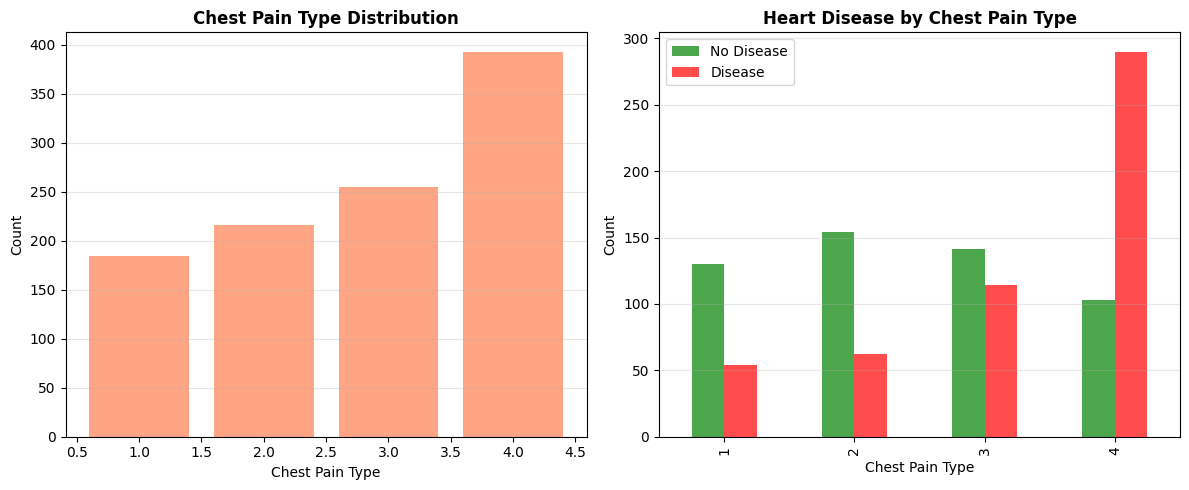

In [16]:
plt.figure(figsize=(12, 5))

# Plot 1: Distribution
plt.subplot(1, 2, 1)
chest_pain_counts = df_pandas['chest pain type'].value_counts().sort_index()
plt.bar(chest_pain_counts.index, chest_pain_counts.values, color='coral', alpha=0.7)
plt.title('Chest Pain Type Distribution', fontweight='bold')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

# Plot 2: Disease vs No Disease
plt.subplot(1, 2, 2)
chest_target = df_pandas.groupby(['chest pain type', 'target']).size().unstack()
chest_target.plot(kind='bar', ax=plt.gca(), color=['green', 'red'], alpha=0.7)
plt.title('Heart Disease by Chest Pain Type', fontweight='bold')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(['No Disease', 'Disease'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


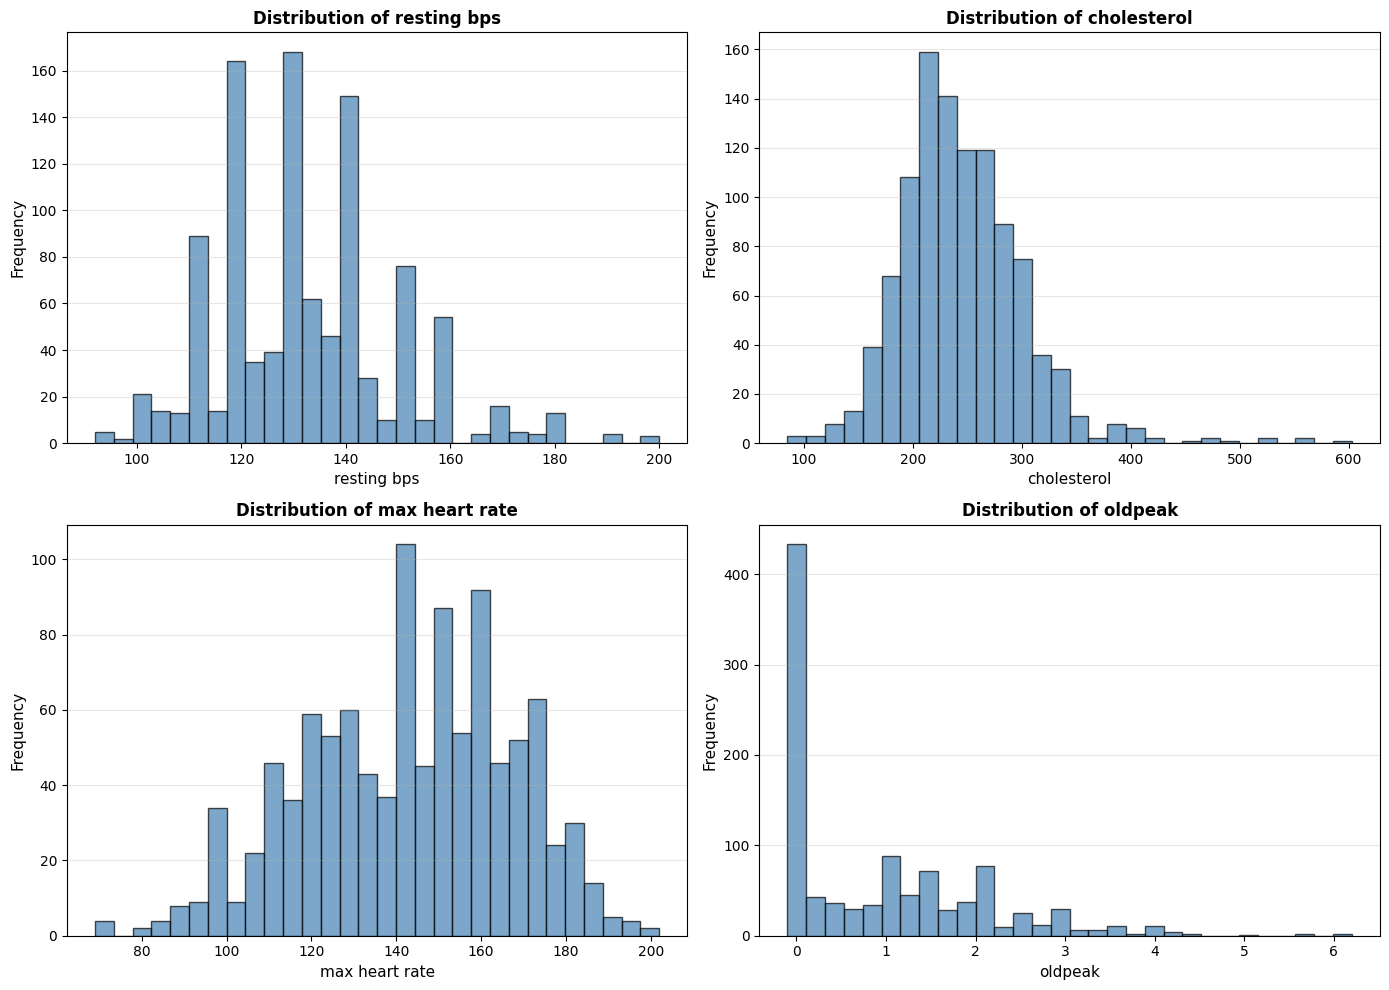

In [17]:
# Key numerical features distribution
numerical_features = ['resting bps', 'cholesterol', 'max heart rate', 'oldpeak']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    axes[idx].hist(df_pandas[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

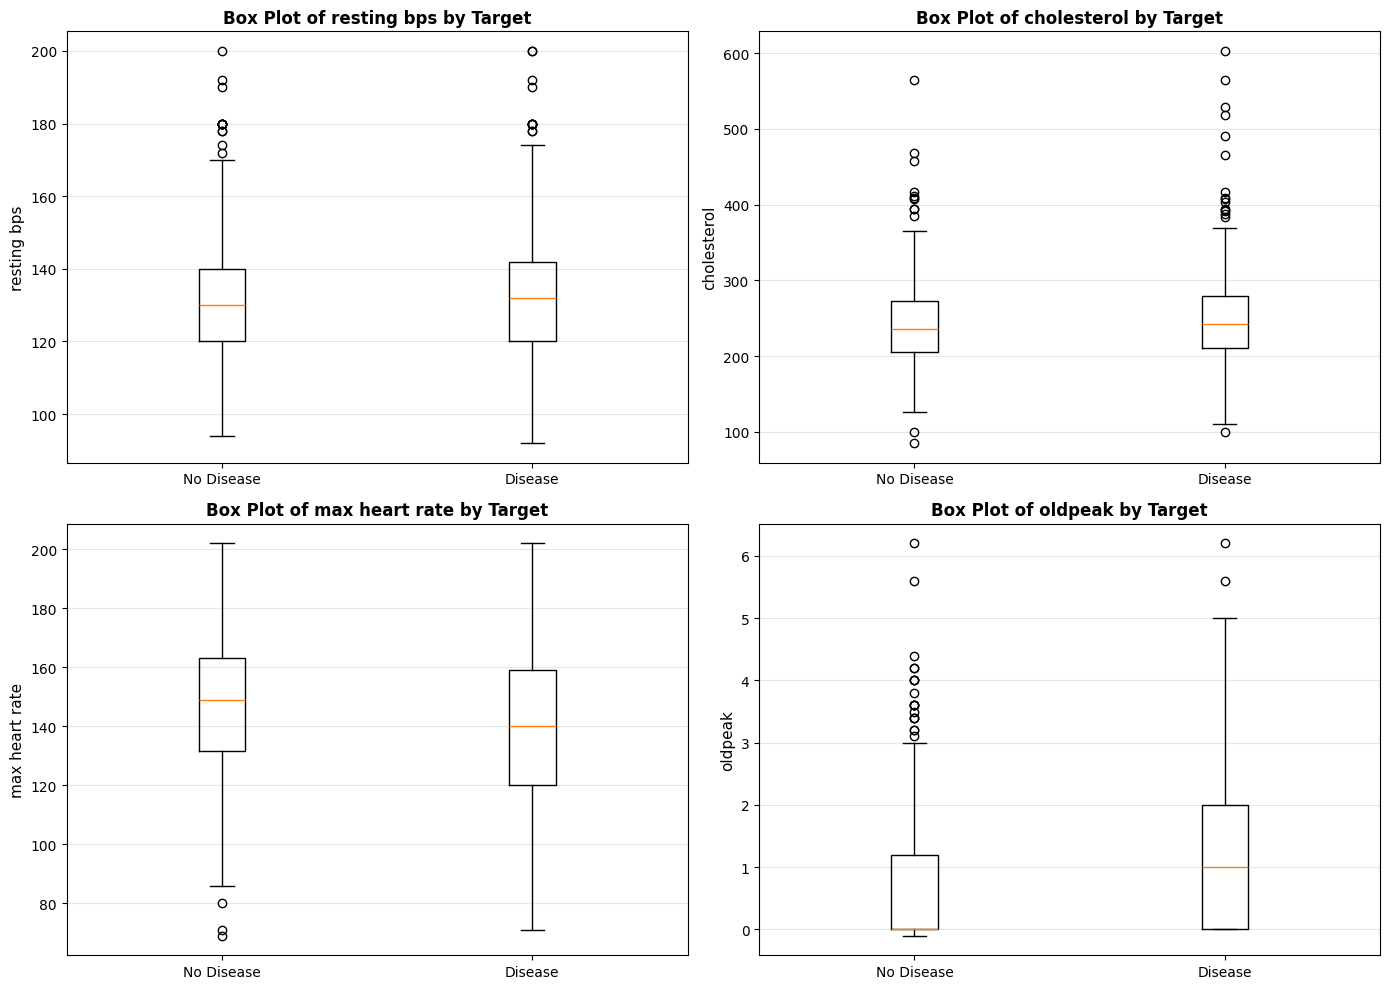

In [18]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    axes[idx].boxplot([df_pandas[df_pandas['target'] == 0][feature].dropna(),
                        df_pandas[df_pandas['target'] == 1][feature].dropna()],
                       labels=['No Disease', 'Disease'])
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].set_title(f'Box Plot of {feature} by Target', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Summary statistics by target variable
print("\n=== Summary Statistics by Target Variable ===")
print("\nWithout Heart Disease (Target = 0):")
df.filter(col('target') == 0).describe().show()

print("\nWith Heart Disease (Target = 1):")
df.filter(col('target') == 1).describe().show()


=== Summary Statistics by Target Variable ===

Without Heart Disease (Target = 0):
+-------+------------------+-----------------+-------------------+------------------+------------------+------------------+-------------------+------------------+-----------------+-------------------+------------------+------------------+------+
|summary|               _c0|              age|                sex|   chest pain type|       resting bps|       cholesterol|fasting blood sugar|       resting ecg|   max heart rate|    exercise angina|           oldpeak|          ST slope|target|
+-------+------------------+-----------------+-------------------+------------------+------------------+------------------+-------------------+------------------+-----------------+-------------------+------------------+------------------+------+
|  count|               528|              528|                528|               528|               528|               528|                528|               528|              52

### Key Insights from Data Exploration:

1. **Target Distribution**: The dataset shows the distribution of patients with and without heart disease.
2. **Age**: Age is an important factor; older patients tend to have higher risk.
3. **Gender**: Heart disease prevalence differs between males and females.
4. **Chest Pain Type**: Different chest pain types show varying correlations with heart disease.
5. **Outliers**: Box plots help identify potential outliers in numerical features.

---
## 3. Data Pre-processing and Cleaning

### 3.a Identifying NULL or Missing Values, Handling Outliers

In [20]:
# Check for NULL values
print("Checking for NULL values in each column:\n")

null_counts = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])
null_counts.show()

Checking for NULL values in each column:

+---+---+---+---------------+-----------+-----------+-------------------+-----------+--------------+---------------+-------+--------+------+
|_c0|age|sex|chest pain type|resting bps|cholesterol|fasting blood sugar|resting ecg|max heart rate|exercise angina|oldpeak|ST slope|target|
+---+---+---+---------------+-----------+-----------+-------------------+-----------+--------------+---------------+-------+--------+------+
|  0|  0|  0|              0|          0|          0|                  0|          0|             0|              0|      0|       0|     0|
+---+---+---+---------------+-----------+-----------+-------------------+-----------+--------------+---------------+-------+--------+------+



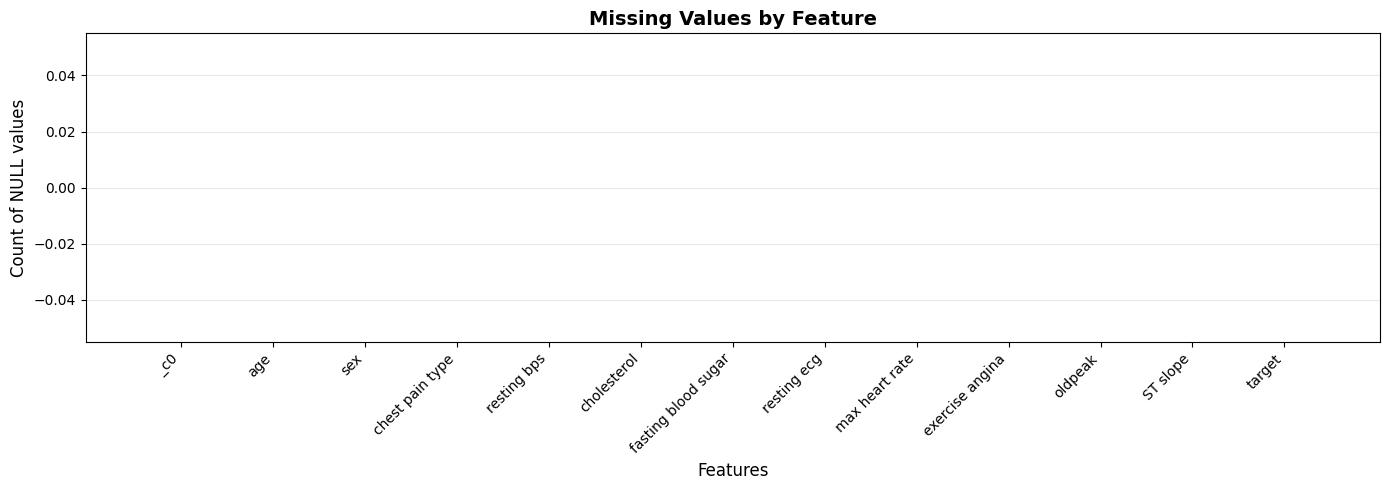


Total NULL values in dataset: 0


In [21]:
# Visualize missing values
null_df = null_counts.toPandas()
null_values = null_df.iloc[0].values

plt.figure(figsize=(14, 5))
plt.bar(df.columns, null_values, color='orange', alpha=0.7)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Count of NULL values', fontsize=12)
plt.title('Missing Values by Feature', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal NULL values in dataset: {sum(null_values)}")

In [22]:
# Handle missing values - Drop rows with NULL values (if any)
# Alternatively, you could fill with mean/median

initial_count = df.count()
df_clean = df.na.drop()
final_count = df_clean.count()

print(f"Initial row count: {initial_count}")
print(f"Final row count after dropping NULLs: {final_count}")
print(f"Rows dropped: {initial_count - final_count}")

Initial row count: 1048
Final row count after dropping NULLs: 1048
Rows dropped: 0


In [23]:
# Check for any zero or invalid values in specific columns
# For example, cholesterol = 0 might be invalid

print("Checking for potentially invalid values:")
print(f"Rows with cholesterol = 0: {df_clean.filter(col('cholesterol') == 0).count()}")
print(f"Rows with resting bps = 0: {df_clean.filter(col('resting bps') == 0).count()}")
print(f"Rows with max heart rate = 0: {df_clean.filter(col('max heart rate') == 0).count()}")

Checking for potentially invalid values:
Rows with cholesterol = 0: 0
Rows with resting bps = 0: 0
Rows with max heart rate = 0: 0


In [24]:
# Handle invalid values (optional - based on data quality)
# For this example, we'll keep the data as is since 0 values might be data entry issues
# but removing them might lose too much data

# If needed, you can filter out rows with invalid values:
# df_clean = df_clean.filter((col('cholesterol') > 0) & (col('resting bps') > 0))

print("Data cleaning completed!")
print(f"Clean dataset shape: ({df_clean.count()}, {len(df_clean.columns)})")

Data cleaning completed!
Clean dataset shape: (1048, 13)


In [25]:
# Outlier detection using IQR method (Interquartile Range)
# We'll identify outliers but not remove them for medical data

numerical_cols = ['age', 'resting bps', 'cholesterol', 'max heart rate', 'oldpeak']

print("Outlier Analysis using IQR method:\n")

for col_name in numerical_cols:
    # Calculate quartiles
    quantiles = df_clean.approxQuantile(col_name, [0.25, 0.75], 0.01)
    Q1, Q3 = quantiles[0], quantiles[1]
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = df_clean.filter((col(col_name) < lower_bound) | (col(col_name) > upper_bound)).count()

    print(f"{col_name}:")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers detected: {outliers_count}")
    print()

Outlier Analysis using IQR method:

age:
  Q1: 46.00, Q3: 59.00, IQR: 13.00
  Bounds: [26.50, 78.50]
  Outliers detected: 0

resting bps:
  Q1: 120.00, Q3: 140.00, IQR: 20.00
  Bounds: [90.00, 170.00]
  Outliers detected: 29

cholesterol:
  Q1: 208.00, Q3: 274.00, IQR: 66.00
  Bounds: [109.00, 373.00]
  Outliers detected: 28

max heart rate:
  Q1: 125.00, Q3: 161.00, IQR: 36.00
  Bounds: [71.00, 215.00]
  Outliers detected: 1

oldpeak:
  Q1: 0.00, Q3: 1.50, IQR: 1.50
  Bounds: [-2.25, 3.75]
  Outliers detected: 24



### 3.b Feature Transformation (Standardization/Normalization)

In [26]:
# First, let's drop the first unnamed column if it exists (index column)
# Check if there's an unnamed column
if '' in df_clean.columns or 'Unnamed: 0' in df_clean.columns:
    drop_col = '' if '' in df_clean.columns else 'Unnamed: 0'
    df_clean = df_clean.drop(drop_col)
    print(f"Dropped column: {drop_col}")

print("Current columns:", df_clean.columns)

Current columns: ['_c0', 'age', 'sex', 'chest pain type', 'resting bps', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'target']


In [27]:
# Define feature columns (all except target)
feature_columns = [col for col in df_clean.columns if col != 'target']

print("Feature columns for transformation:")
print(feature_columns)

Feature columns for transformation:
['_c0', 'age', 'sex', 'chest pain type', 'resting bps', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope']


In [28]:
# Create a vector of all features
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features_raw")
df_assembled = assembler.transform(df_clean)

print("✓ Features assembled into vector column")

✓ Features assembled into vector column


In [29]:
# Apply StandardScaler (Standardization: mean=0, std=1)
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled",
                        withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

print("✓ Standard Scaling applied (Z-score normalization)")
print("  Mean = 0, Standard Deviation = 1")

✓ Standard Scaling applied (Z-score normalization)
  Mean = 0, Standard Deviation = 1


In [30]:
# Also create MinMax normalized features (optional, for comparison)
minmax_scaler = MinMaxScaler(inputCol="features_raw", outputCol="features_normalized")
minmax_model = minmax_scaler.fit(df_assembled)
df_normalized = minmax_model.transform(df_scaled)

print("✓ Min-Max Normalization applied (scaled to [0, 1])")

✓ Min-Max Normalization applied (scaled to [0, 1])


In [31]:
# Show sample of transformed data
print("\nSample of transformed data:")
df_normalized.select('target', 'features_raw', 'features_scaled').show(5, truncate=False)


Sample of transformed data:
+------+--------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|target|features_raw                                            |features_scaled                                                                                                                                                                                                                              |
+------+--------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|0     |[0.0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0

### 3.c Correlation Analysis

In [32]:
# Calculate correlation matrix using PySpark
correlation_matrix = Correlation.corr(df_normalized, 'features_raw').collect()[0][0]
correlation_array = correlation_matrix.toArray()

print("Correlation matrix calculated")
print(f"Matrix shape: {correlation_array.shape}")

Correlation matrix calculated
Matrix shape: (12, 12)


In [33]:
# Create a DataFrame for better visualization
correlation_df = pd.DataFrame(correlation_array,
                               columns=feature_columns,
                               index=feature_columns)

print("\nCorrelation Matrix:")
print(correlation_df)


Correlation Matrix:
                          _c0       age       sex  chest pain type  \
_c0                  1.000000  0.201977  0.022079         0.299323   
age                  0.201977  1.000000 -0.004727         0.054615   
sex                  0.022079 -0.004727  1.000000         0.108897   
chest pain type      0.299323  0.054615  0.108897         1.000000   
resting bps          0.019601  0.262620  0.008786         0.056790   
cholesterol         -0.026290  0.096891 -0.131711         0.025628   
fasting blood sugar  0.081140  0.206304  0.082642         0.062464   
resting ecg          0.330436  0.155920 -0.017819         0.092742   
max heart rate       0.028989 -0.365829 -0.135492        -0.221201   
exercise angina      0.039248  0.199733  0.181000         0.198775   
oldpeak              0.095157  0.265204  0.111965         0.104195   
ST slope             0.178130  0.139789  0.095621         0.301401   

                     resting bps  cholesterol  fasting blood sugar  

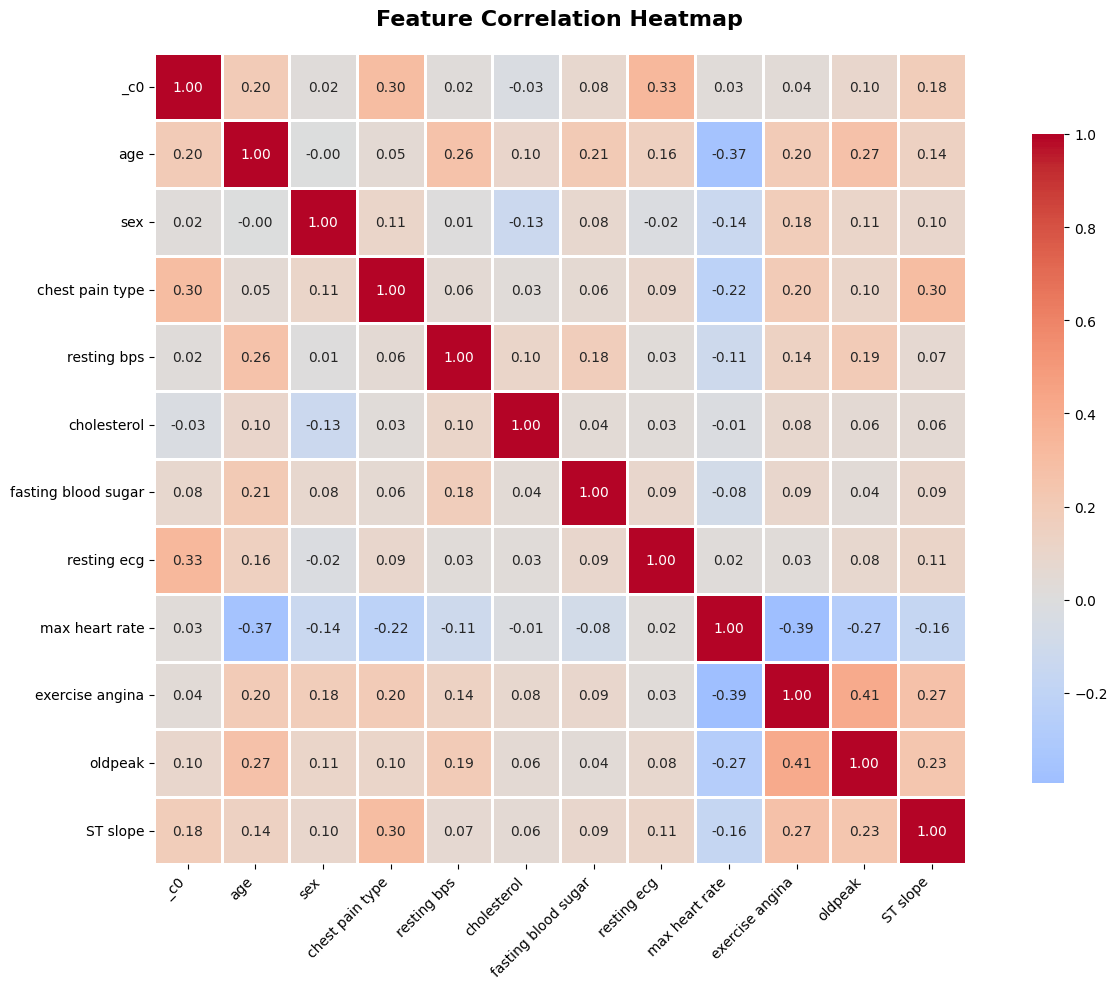

In [34]:
# Visualize correlation matrix using heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_df, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
# Calculate correlation with target variable
print("\nCorrelation of features with Target variable:")
print("="*50)

for feature in feature_columns:
    correlation = df_clean.stat.corr(feature, 'target')
    print(f"{feature:20s}: {correlation:+.4f}")


Correlation of features with Target variable:
_c0                 : +0.0621
age                 : +0.1580
sex                 : +0.1121
chest pain type     : +0.3666
resting bps         : +0.0779
cholesterol         : +0.0562
fasting blood sugar : +0.1069
resting ecg         : +0.1111
max heart rate      : -0.1460
exercise angina     : +0.2709
oldpeak             : +0.2172
ST slope            : +0.5035


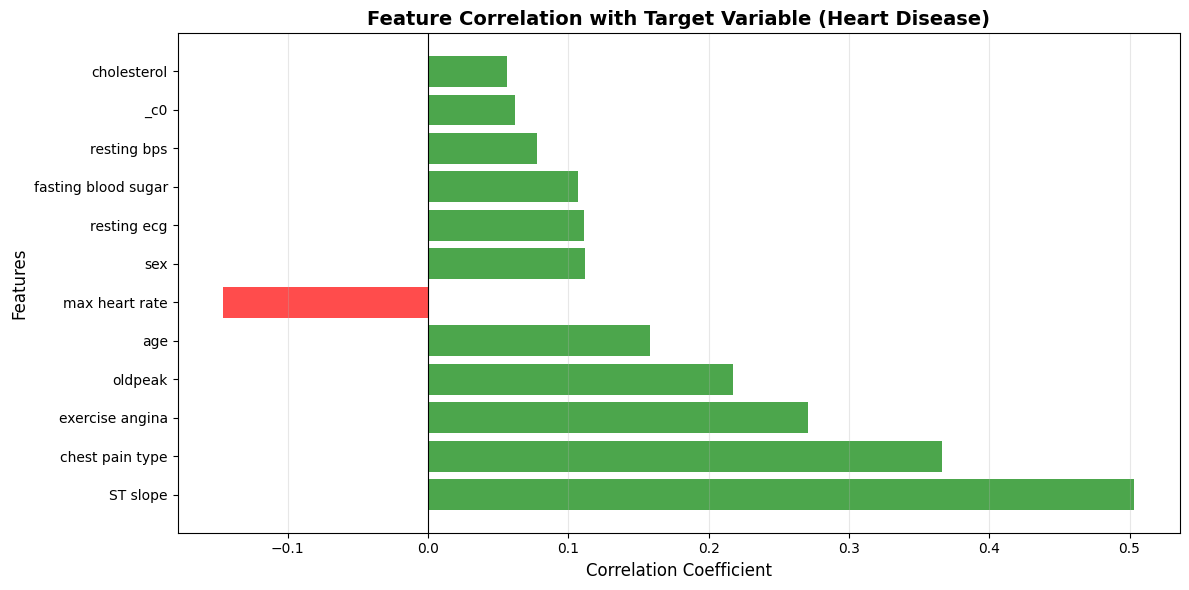

In [36]:
# Visualize feature correlations with target
target_correlations = {}
for feature in feature_columns:
    target_correlations[feature] = df_clean.stat.corr(feature, 'target')

plt.figure(figsize=(12, 6))
features_sorted = sorted(target_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
features_names = [x[0] for x in features_sorted]
features_values = [x[1] for x in features_sorted]

colors = ['red' if x < 0 else 'green' for x in features_values]
plt.barh(features_names, features_values, color=colors, alpha=0.7)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Correlation with Target Variable (Heart Disease)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Data Preparation

### 4.a Final Feature Selection
### 4.b Train-Test Split

In [37]:
# Select final features and target
# We'll use the standardized features for modeling

final_df = df_normalized.select('features_scaled', 'target')
final_df = final_df.withColumnRenamed('features_scaled', 'features')

print("Final dataset prepared for modeling:")
print(f"Number of features: {len(feature_columns)}")
print(f"Feature names: {feature_columns}")
print(f"Target variable: target")
print(f"Total records: {final_df.count()}")

Final dataset prepared for modeling:
Number of features: 12
Feature names: ['_c0', 'age', 'sex', 'chest pain type', 'resting bps', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope']
Target variable: target
Total records: 1048


In [38]:
# Display sample of final prepared data
print("\nSample of final prepared data:")
final_df.show(10, truncate=False)


Sample of final prepared data:
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+
|features                                                                                                                                                                                                                                        |target|
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+
|[-1.2693098094910489,-1.4179224021317118,0.6005784363541055,-0.7310141085522098,0.42530045913263925,0.7675349764227892,-0.439814863540129,-0.7950480688292085,1.1905256336501373,-0.7632333820347053,-0.8563625610209957,

In [39]:
# Split data into training and testing sets (70-30 split)
train_data, test_data = final_df.randomSplit([0.7, 0.3], seed=42)

print("Train-Test Split completed:")
print(f"Training set size: {train_data.count()} ({train_data.count()/final_df.count()*100:.1f}%)")
print(f"Testing set size: {test_data.count()} ({test_data.count()/final_df.count()*100:.1f}%)")

Train-Test Split completed:
Training set size: 775 (74.0%)
Testing set size: 273 (26.0%)


In [40]:
# Check class distribution in train and test sets
print("\nTarget distribution in Training set:")
train_data.groupBy('target').count().show()

print("Target distribution in Testing set:")
test_data.groupBy('target').count().show()


Target distribution in Training set:
+------+-----+
|target|count|
+------+-----+
|     1|  377|
|     0|  398|
+------+-----+

Target distribution in Testing set:
+------+-----+
|target|count|
+------+-----+
|     1|  143|
|     0|  130|
+------+-----+



In [41]:
# Cache the datasets for faster processing
train_data.cache()
test_data.cache()

print("✓ Training and testing datasets cached for optimal performance")

✓ Training and testing datasets cached for optimal performance


---
## 5. Model Building

We will build and train **THREE** different Machine Learning models:
1. **Logistic Regression**
2. **Random Forest Classifier**
3. **Gradient Boosted Trees (GBT) Classifier**

### 5.a Model Development
### 5.b Training and Evaluation

### Model 1: Logistic Regression

In [42]:
print("="*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*60)

# Initialize Logistic Regression
lr = LogisticRegression(featuresCol='features', labelCol='target', maxIter=100, regParam=0.01)

# Train the model
print("\nTraining Logistic Regression model...")
lr_model = lr.fit(train_data)
print("✓ Training completed!")

# Make predictions on training data
lr_train_predictions = lr_model.transform(train_data)

# Training accuracy
lr_train_evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='accuracy')
lr_train_accuracy = lr_train_evaluator.evaluate(lr_train_predictions)

print(f"\nTraining Accuracy: {lr_train_accuracy:.4f} ({lr_train_accuracy*100:.2f}%)")

# Get training summary
training_summary = lr_model.summary
print(f"\nTraining Metrics:")
print(f"  Total Iterations: {training_summary.totalIterations}")
print(f"  Objective History (Loss): {training_summary.objectiveHistory[-1]:.6f}")

MODEL 1: LOGISTIC REGRESSION

Training Logistic Regression model...
✓ Training completed!

Training Accuracy: 0.7910 (79.10%)

Training Metrics:
  Total Iterations: 12
  Objective History (Loss): 0.490803


### Model 2: Random Forest Classifier

In [43]:
print("="*60)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("="*60)

# Initialize Random Forest
rf = RandomForestClassifier(featuresCol='features', labelCol='target',
                             numTrees=100, maxDepth=10, seed=42)

# Train the model
print("\nTraining Random Forest model...")
rf_model = rf.fit(train_data)
print("✓ Training completed!")

# Make predictions on training data
rf_train_predictions = rf_model.transform(train_data)

# Training accuracy
rf_train_evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='accuracy')
rf_train_accuracy = rf_train_evaluator.evaluate(rf_train_predictions)

print(f"\nTraining Accuracy: {rf_train_accuracy:.4f} ({rf_train_accuracy*100:.2f}%)")

# Feature importance
print("\nFeature Importance:")
feature_importance = rf_model.featureImportances.toArray()
for idx, (feature, importance) in enumerate(zip(feature_columns, feature_importance)):
    print(f"  {feature:20s}: {importance:.4f}")

MODEL 2: RANDOM FOREST CLASSIFIER

Training Random Forest model...
✓ Training completed!

Training Accuracy: 0.9948 (99.48%)

Feature Importance:
  _c0                 : 0.1178
  age                 : 0.0734
  sex                 : 0.0231
  chest pain type     : 0.1243
  resting bps         : 0.0715
  cholesterol         : 0.0640
  fasting blood sugar : 0.0091
  resting ecg         : 0.0283
  max heart rate      : 0.0841
  exercise angina     : 0.0327
  oldpeak             : 0.1017
  ST slope            : 0.2699


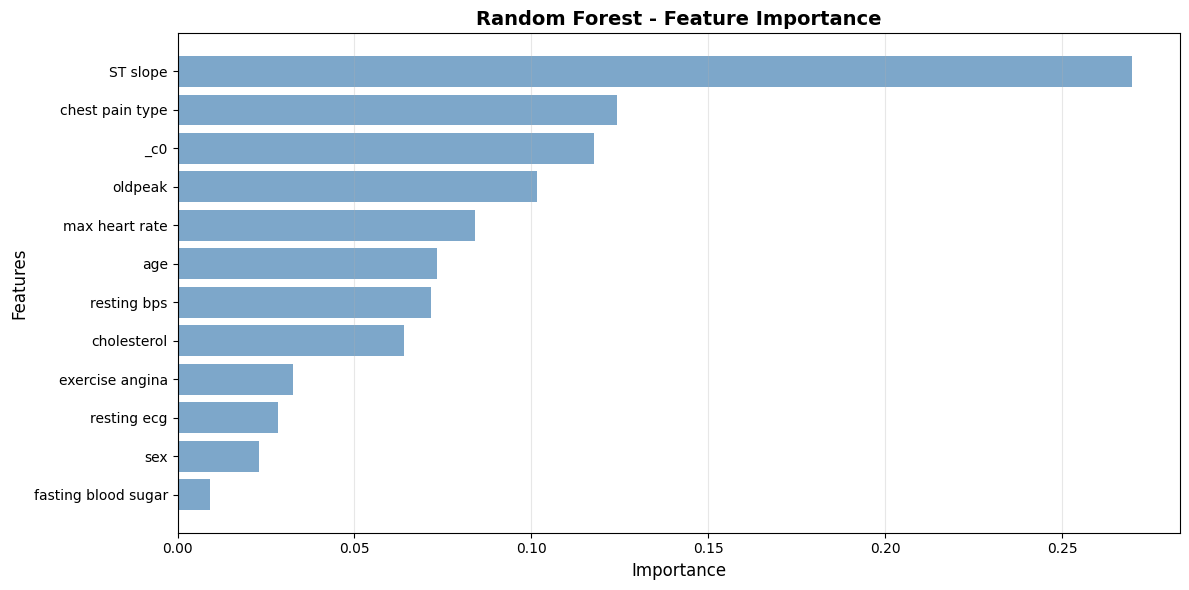

In [44]:
# Visualize feature importance
plt.figure(figsize=(12, 6))
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=True)

plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue', alpha=0.7)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Model 3: Gradient Boosted Trees (GBT) Classifier

In [45]:
print("="*60)
print("MODEL 3: GRADIENT BOOSTED TREES (GBT) CLASSIFIER")
print("="*60)

# Initialize GBT
gbt = GBTClassifier(featuresCol='features', labelCol='target',
                    maxIter=50, maxDepth=5, seed=42)

# Train the model
print("\nTraining GBT model...")
gbt_model = gbt.fit(train_data)
print("✓ Training completed!")

# Make predictions on training data
gbt_train_predictions = gbt_model.transform(train_data)

# Training accuracy
gbt_train_evaluator = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='accuracy')
gbt_train_accuracy = gbt_train_evaluator.evaluate(gbt_train_predictions)

print(f"\nTraining Accuracy: {gbt_train_accuracy:.4f} ({gbt_train_accuracy*100:.2f}%)")

# Feature importance
print("\nFeature Importance:")
gbt_feature_importance = gbt_model.featureImportances.toArray()
for idx, (feature, importance) in enumerate(zip(feature_columns, gbt_feature_importance)):
    print(f"  {feature:20s}: {importance:.4f}")

MODEL 3: GRADIENT BOOSTED TREES (GBT) CLASSIFIER

Training GBT model...
✓ Training completed!

Training Accuracy: 0.9832 (98.32%)

Feature Importance:
  _c0                 : 0.1384
  age                 : 0.1343
  sex                 : 0.0268
  chest pain type     : 0.0804
  resting bps         : 0.0976
  cholesterol         : 0.1007
  fasting blood sugar : 0.0092
  resting ecg         : 0.0183
  max heart rate      : 0.1233
  exercise angina     : 0.0403
  oldpeak             : 0.0988
  ST slope            : 0.1318


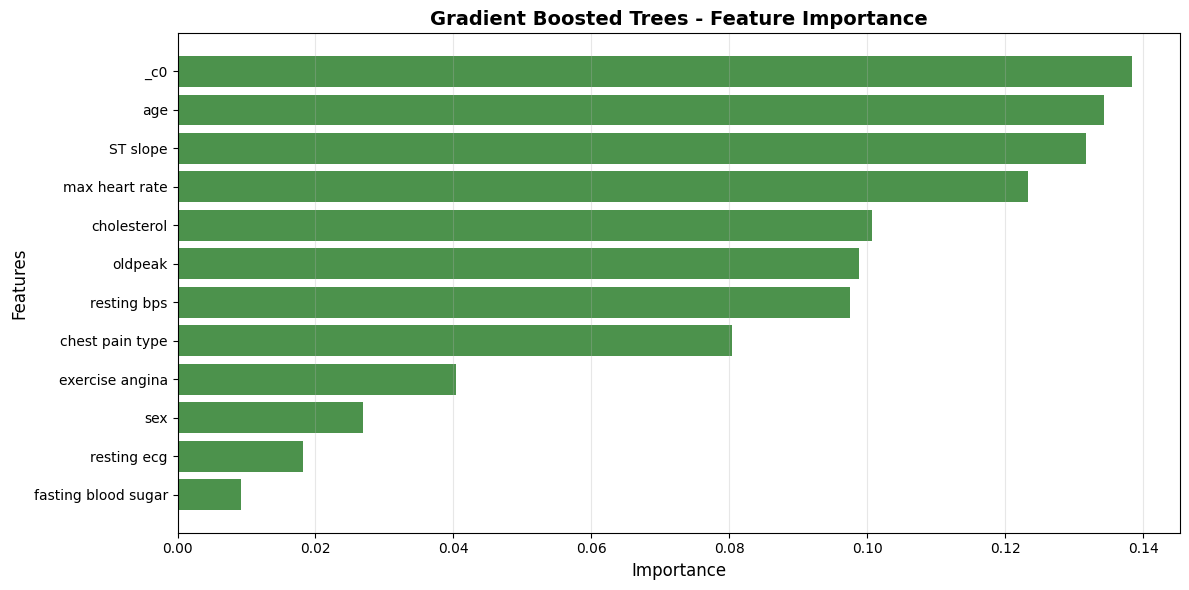

In [46]:
# Visualize GBT feature importance
plt.figure(figsize=(12, 6))
gbt_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': gbt_feature_importance
}).sort_values('Importance', ascending=True)

plt.barh(gbt_importance_df['Feature'], gbt_importance_df['Importance'], color='darkgreen', alpha=0.7)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Gradient Boosted Trees - Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


TRAINING PERFORMANCE SUMMARY
                 Model  Training Accuracy
   Logistic Regression           0.790968
         Random Forest           0.994839
Gradient Boosted Trees           0.983226


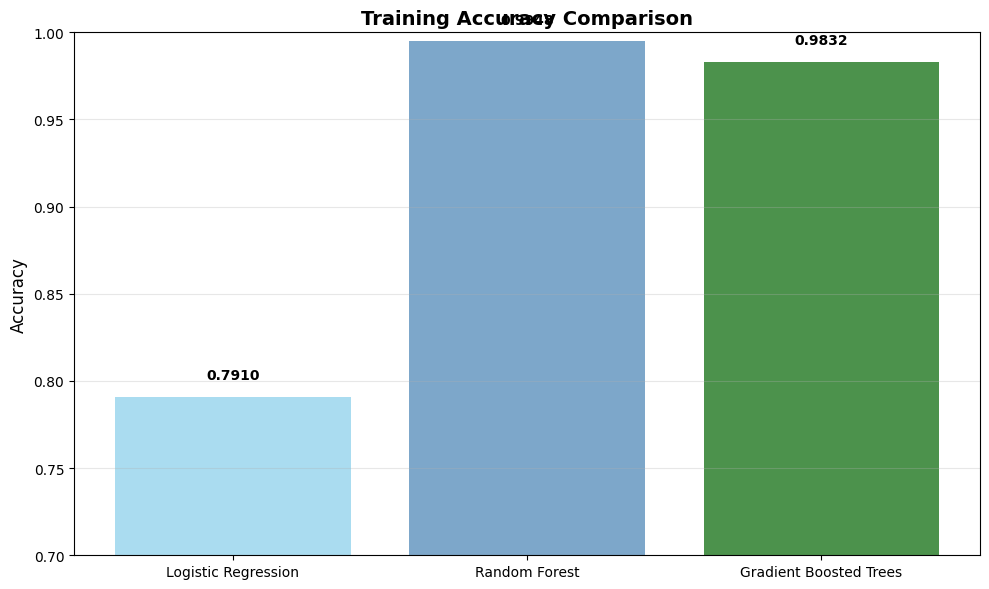

In [47]:
# Summary of Training Performance
print("\n" + "="*60)
print("TRAINING PERFORMANCE SUMMARY")
print("="*60)

training_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosted Trees'],
    'Training Accuracy': [lr_train_accuracy, rf_train_accuracy, gbt_train_accuracy]
})

print(training_results.to_string(index=False))

# Visualize training accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(training_results['Model'], training_results['Training Accuracy'],
        color=['skyblue', 'steelblue', 'darkgreen'], alpha=0.7)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim([0.7, 1.0])
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(training_results['Training Accuracy']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Performance Evaluation

### 6.a Confusion Matrix and Analysis
### 6.b Predictions on Test Data

### Test Set Evaluation - Model 1: Logistic Regression

In [48]:
print("="*60)
print("TEST SET EVALUATION - LOGISTIC REGRESSION")
print("="*60)

# Make predictions on test data
lr_test_predictions = lr_model.transform(test_data)

# Display sample predictions
print("\nSample Predictions:")
lr_test_predictions.select('features', 'target', 'prediction', 'probability').show(10, truncate=False)

TEST SET EVALUATION - LOGISTIC REGRESSION

Sample Predictions:
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+----------+----------------------------------------+
|features                                                                                                                                                                                                                                        |target|prediction|probability                             |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+----------+----------------------------------------+
|[-1.266062177203251,-0.4602536

In [49]:
# Calculate test metrics
lr_test_evaluator_acc = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='accuracy')
lr_test_evaluator_prec = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='weightedPrecision')
lr_test_evaluator_rec = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='weightedRecall')
lr_test_evaluator_f1 = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='f1')

lr_test_accuracy = lr_test_evaluator_acc.evaluate(lr_test_predictions)
lr_test_precision = lr_test_evaluator_prec.evaluate(lr_test_predictions)
lr_test_recall = lr_test_evaluator_rec.evaluate(lr_test_predictions)
lr_test_f1 = lr_test_evaluator_f1.evaluate(lr_test_predictions)

print("\nTest Set Performance Metrics:")
print(f"  Accuracy:  {lr_test_accuracy:.4f} ({lr_test_accuracy*100:.2f}%)")
print(f"  Precision: {lr_test_precision:.4f}")
print(f"  Recall:    {lr_test_recall:.4f}")
print(f"  F1-Score:  {lr_test_f1:.4f}")


Test Set Performance Metrics:
  Accuracy:  0.7766 (77.66%)
  Precision: 0.7765
  Recall:    0.7766
  F1-Score:  0.7765



Confusion Matrix:
[[ 99.  31.]
 [ 30. 113.]]


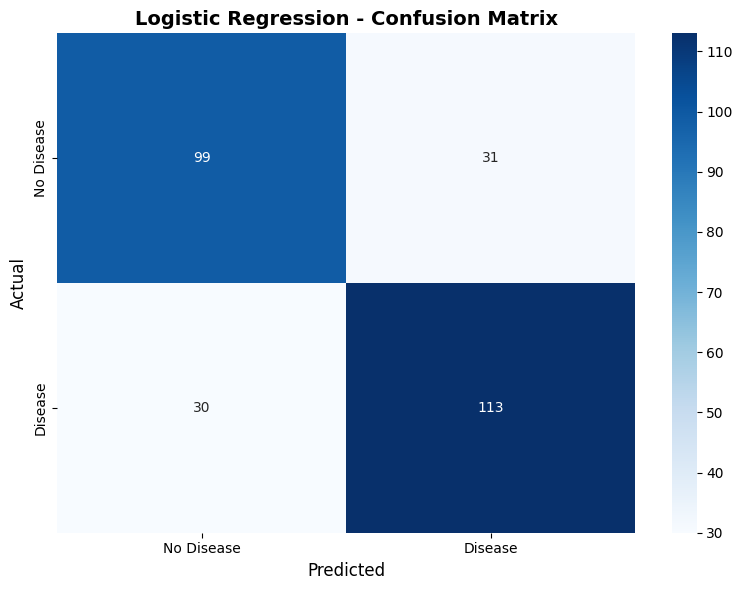


Confusion Matrix Analysis:
  True Negatives (TN):  99
  False Positives (FP): 31
  False Negatives (FN): 30
  True Positives (TP):  113

  Sensitivity (Recall): 0.7902
  Specificity:          0.7615


In [50]:
# Confusion Matrix for Logistic Regression
lr_pred_and_labels = lr_test_predictions.select('prediction', 'target').rdd.map(lambda row: (float(row['prediction']), float(row['target'])))
lr_metrics = MulticlassMetrics(lr_pred_and_labels)
lr_confusion_matrix = lr_metrics.confusionMatrix().toArray()

print("\nConfusion Matrix:")
print(lr_confusion_matrix)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(lr_confusion_matrix, annot=True, fmt='g', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate True Positives, False Positives, True Negatives, False Negatives
tn, fp, fn, tp = lr_confusion_matrix[0][0], lr_confusion_matrix[0][1], lr_confusion_matrix[1][0], lr_confusion_matrix[1][1]
print(f"\nConfusion Matrix Analysis:")
print(f"  True Negatives (TN):  {int(tn)}")
print(f"  False Positives (FP): {int(fp)}")
print(f"  False Negatives (FN): {int(fn)}")
print(f"  True Positives (TP):  {int(tp)}")
print(f"\n  Sensitivity (Recall): {tp/(tp+fn):.4f}")
print(f"  Specificity:          {tn/(tn+fp):.4f}")

### Test Set Evaluation - Model 2: Random Forest

In [51]:
print("="*60)
print("TEST SET EVALUATION - RANDOM FOREST")
print("="*60)

# Make predictions on test data
rf_test_predictions = rf_model.transform(test_data)

# Display sample predictions
print("\nSample Predictions:")
rf_test_predictions.select('features', 'target', 'prediction', 'probability').show(10, truncate=False)

TEST SET EVALUATION - RANDOM FOREST

Sample Predictions:
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+----------+-----------------------------------------+
|features                                                                                                                                                                                                                                        |target|prediction|probability                              |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+----------+-----------------------------------------+
|[-1.266062177203251,-0.4602536519

In [52]:
# Calculate test metrics
rf_test_evaluator_acc = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='accuracy')
rf_test_evaluator_prec = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='weightedPrecision')
rf_test_evaluator_rec = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='weightedRecall')
rf_test_evaluator_f1 = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='f1')

rf_test_accuracy = rf_test_evaluator_acc.evaluate(rf_test_predictions)
rf_test_precision = rf_test_evaluator_prec.evaluate(rf_test_predictions)
rf_test_recall = rf_test_evaluator_rec.evaluate(rf_test_predictions)
rf_test_f1 = rf_test_evaluator_f1.evaluate(rf_test_predictions)

print("\nTest Set Performance Metrics:")
print(f"  Accuracy:  {rf_test_accuracy:.4f} ({rf_test_accuracy*100:.2f}%)")
print(f"  Precision: {rf_test_precision:.4f}")
print(f"  Recall:    {rf_test_recall:.4f}")
print(f"  F1-Score:  {rf_test_f1:.4f}")


Test Set Performance Metrics:
  Accuracy:  0.7802 (78.02%)
  Precision: 0.7833
  Recall:    0.7802
  F1-Score:  0.7803



Confusion Matrix:
[[106.  24.]
 [ 36. 107.]]


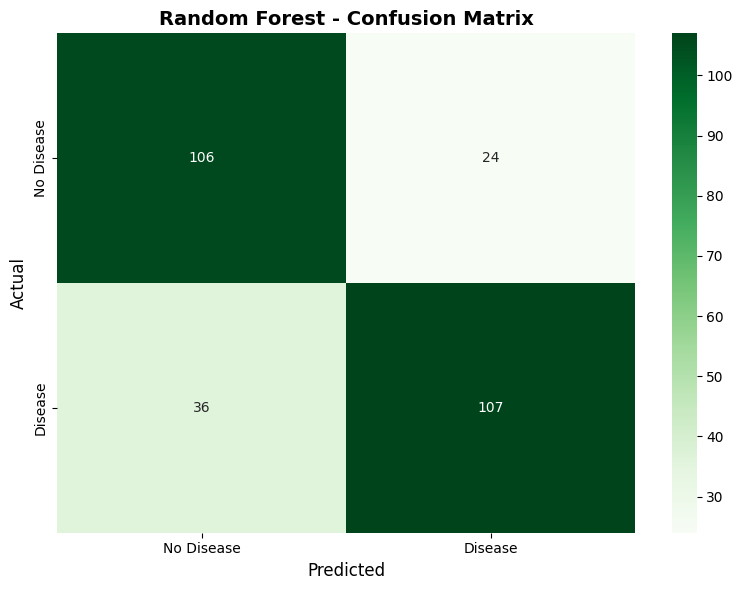


Confusion Matrix Analysis:
  True Negatives (TN):  106
  False Positives (FP): 24
  False Negatives (FN): 36
  True Positives (TP):  107

  Sensitivity (Recall): 0.7483
  Specificity:          0.8154


In [53]:
# Confusion Matrix for Random Forest
rf_pred_and_labels = rf_test_predictions.select('prediction', 'target').rdd.map(lambda row: (float(row['prediction']), float(row['target'])))
rf_metrics = MulticlassMetrics(rf_pred_and_labels)
rf_confusion_matrix = rf_metrics.confusionMatrix().toArray()

print("\nConfusion Matrix:")
print(rf_confusion_matrix)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(rf_confusion_matrix, annot=True, fmt='g', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate metrics
tn, fp, fn, tp = rf_confusion_matrix[0][0], rf_confusion_matrix[0][1], rf_confusion_matrix[1][0], rf_confusion_matrix[1][1]
print(f"\nConfusion Matrix Analysis:")
print(f"  True Negatives (TN):  {int(tn)}")
print(f"  False Positives (FP): {int(fp)}")
print(f"  False Negatives (FN): {int(fn)}")
print(f"  True Positives (TP):  {int(tp)}")
print(f"\n  Sensitivity (Recall): {tp/(tp+fn):.4f}")
print(f"  Specificity:          {tn/(tn+fp):.4f}")

### Test Set Evaluation - Model 3: Gradient Boosted Trees

In [54]:
print("="*60)
print("TEST SET EVALUATION - GRADIENT BOOSTED TREES")
print("="*60)

# Make predictions on test data
gbt_test_predictions = gbt_model.transform(test_data)

# Display sample predictions
print("\nSample Predictions:")
gbt_test_predictions.select('features', 'target', 'prediction', 'probability').show(10, truncate=False)

TEST SET EVALUATION - GRADIENT BOOSTED TREES

Sample Predictions:
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+----------+-----------------------------------------+
|features                                                                                                                                                                                                                                        |target|prediction|probability                              |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+----------+-----------------------------------------+
|[-1.266062177203251,-0.4

In [55]:
# Calculate test metrics
gbt_test_evaluator_acc = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='accuracy')
gbt_test_evaluator_prec = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='weightedPrecision')
gbt_test_evaluator_rec = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='weightedRecall')
gbt_test_evaluator_f1 = MulticlassClassificationEvaluator(labelCol='target', predictionCol='prediction', metricName='f1')

gbt_test_accuracy = gbt_test_evaluator_acc.evaluate(gbt_test_predictions)
gbt_test_precision = gbt_test_evaluator_prec.evaluate(gbt_test_predictions)
gbt_test_recall = gbt_test_evaluator_rec.evaluate(gbt_test_predictions)
gbt_test_f1 = gbt_test_evaluator_f1.evaluate(gbt_test_predictions)

print("\nTest Set Performance Metrics:")
print(f"  Accuracy:  {gbt_test_accuracy:.4f} ({gbt_test_accuracy*100:.2f}%)")
print(f"  Precision: {gbt_test_precision:.4f}")
print(f"  Recall:    {gbt_test_recall:.4f}")
print(f"  F1-Score:  {gbt_test_f1:.4f}")


Test Set Performance Metrics:
  Accuracy:  0.7253 (72.53%)
  Precision: 0.7315
  Recall:    0.7253
  F1-Score:  0.7249



Confusion Matrix:
[[102.  28.]
 [ 47.  96.]]


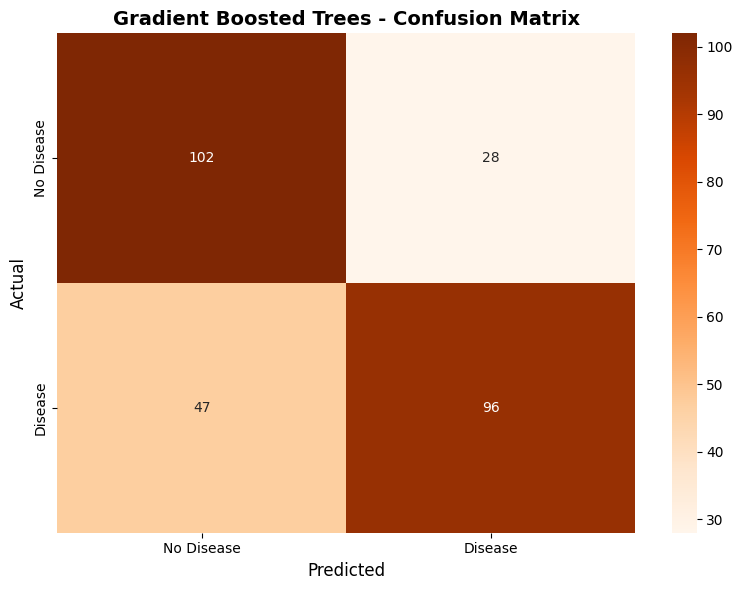


Confusion Matrix Analysis:
  True Negatives (TN):  102
  False Positives (FP): 28
  False Negatives (FN): 47
  True Positives (TP):  96

  Sensitivity (Recall): 0.6713
  Specificity:          0.7846


In [56]:
# Confusion Matrix for GBT
gbt_pred_and_labels = gbt_test_predictions.select('prediction', 'target').rdd.map(lambda row: (float(row['prediction']), float(row['target'])))
gbt_metrics = MulticlassMetrics(gbt_pred_and_labels)
gbt_confusion_matrix = gbt_metrics.confusionMatrix().toArray()

print("\nConfusion Matrix:")
print(gbt_confusion_matrix)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(gbt_confusion_matrix, annot=True, fmt='g', cmap='Oranges',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Gradient Boosted Trees - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate metrics
tn, fp, fn, tp = gbt_confusion_matrix[0][0], gbt_confusion_matrix[0][1], gbt_confusion_matrix[1][0], gbt_confusion_matrix[1][1]
print(f"\nConfusion Matrix Analysis:")
print(f"  True Negatives (TN):  {int(tn)}")
print(f"  False Positives (FP): {int(fp)}")
print(f"  False Negatives (FN): {int(fn)}")
print(f"  True Positives (TP):  {int(tp)}")
print(f"\n  Sensitivity (Recall): {tp/(tp+fn):.4f}")
print(f"  Specificity:          {tn/(tn+fp):.4f}")

### Final Model Comparison and Results

In [57]:
# Final comparison of all models
print("\n" + "="*80)
print("FINAL MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*80)

results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosted Trees'],
    'Accuracy': [lr_test_accuracy, rf_test_accuracy, gbt_test_accuracy],
    'Precision': [lr_test_precision, rf_test_precision, gbt_test_precision],
    'Recall': [lr_test_recall, rf_test_recall, gbt_test_recall],
    'F1-Score': [lr_test_f1, rf_test_f1, gbt_test_f1]
})

print("\n", results_df.to_string(index=False))

# Find best model
best_model_idx = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_accuracy = results_df.loc[best_model_idx, 'Accuracy']

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name}")
print(f"Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"{'='*80}")


FINAL MODEL COMPARISON - TEST SET PERFORMANCE

                  Model  Accuracy  Precision   Recall  F1-Score
   Logistic Regression  0.776557   0.776493 0.776557  0.776515
         Random Forest  0.780220   0.783311 0.780220  0.780255
Gradient Boosted Trees  0.725275   0.731513 0.725275  0.724854

BEST MODEL: Random Forest
Test Accuracy: 0.7802 (78.02%)


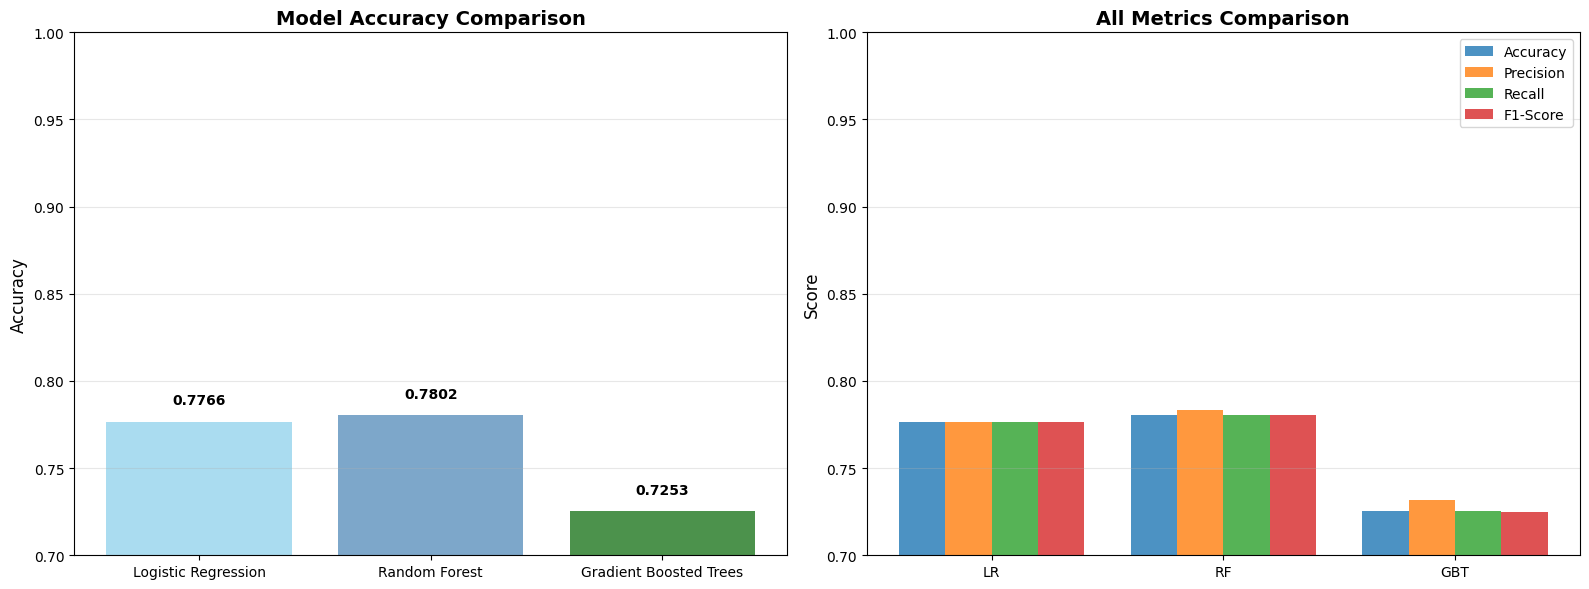

In [58]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
axes[0].bar(results_df['Model'], results_df['Accuracy'],
            color=['skyblue', 'steelblue', 'darkgreen'], alpha=0.7)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0.7, 1.0])
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# All metrics comparison
x = np.arange(len(results_df))
width = 0.2
axes[1].bar(x - width*1.5, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
axes[1].bar(x - width*0.5, results_df['Precision'], width, label='Precision', alpha=0.8)
axes[1].bar(x + width*0.5, results_df['Recall'], width, label='Recall', alpha=0.8)
axes[1].bar(x + width*1.5, results_df['F1-Score'], width, label='F1-Score', alpha=0.8)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['LR', 'RF', 'GBT'])
axes[1].legend()
axes[1].set_ylim([0.7, 1.0])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Detailed Prediction Results and Inference

In [59]:
# Display detailed predictions from the best model
print("\n" + "="*80)
print("DETAILED PREDICTIONS FROM BEST MODEL")
print("="*80)

# Select best model predictions
if best_model_name == 'Logistic Regression':
    best_predictions = lr_test_predictions
elif best_model_name == 'Random Forest':
    best_predictions = rf_test_predictions
else:
    best_predictions = gbt_test_predictions

# Show sample predictions with probabilities
print("\nSample Predictions (First 20 rows):")
best_predictions.select('target', 'prediction', 'probability').show(20, truncate=False)


DETAILED PREDICTIONS FROM BEST MODEL

Sample Predictions (First 20 rows):
+------+----------+-----------------------------------------+
|target|prediction|probability                              |
+------+----------+-----------------------------------------+
|1     |1.0       |[0.4133419191919192,0.5866580808080808]  |
|1     |1.0       |[0.37,0.63]                              |
|0     |0.0       |[0.9234342472693702,0.07656575273062984] |
|0     |0.0       |[0.7262430555555556,0.27375694444444443] |
|0     |0.0       |[0.7605208333333333,0.23947916666666663] |
|0     |0.0       |[0.9632002151152206,0.036799784884779405]|
|0     |0.0       |[0.8497255952380952,0.15027440476190476] |
|0     |0.0       |[0.9452261269363622,0.05477387306363788] |
|1     |0.0       |[0.686933252123938,0.313066747876062]    |
|1     |1.0       |[0.35968569065343253,0.6403143093465674] |
|1     |1.0       |[0.46132556332556335,0.5386744366744367] |
|0     |0.0       |[0.8678382394342526,0.1321617605657473


Prediction Confidence Statistics:
count    273.000000
mean       0.786283
std        0.142862
min        0.500000
25%        0.669260
50%        0.814000
75%        0.907801
max        0.999348
Name: confidence, dtype: float64


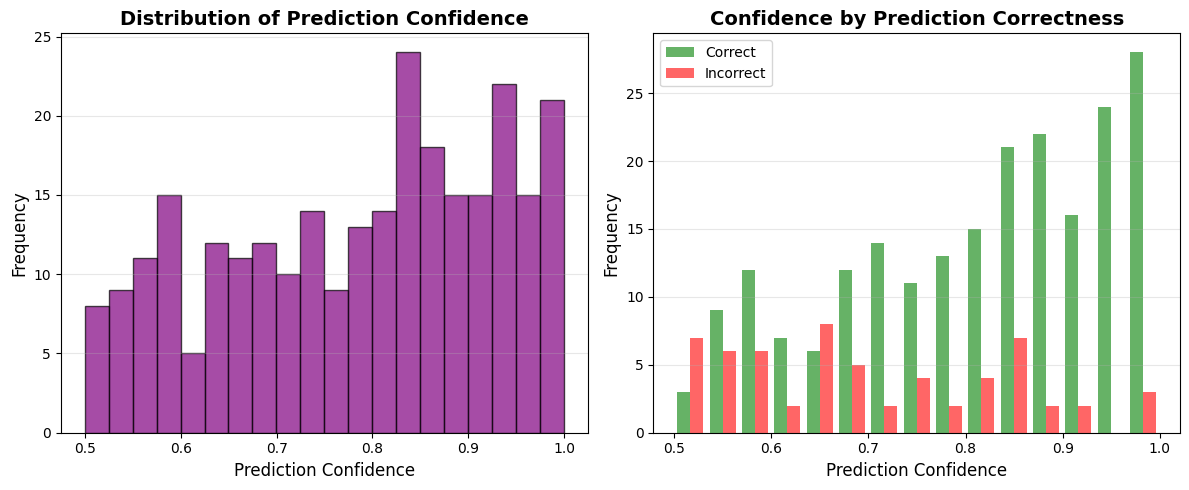

In [60]:
# Analyze prediction confidence
predictions_pandas = best_predictions.select('target', 'prediction', 'probability').toPandas()

# Extract probability for predicted class
def get_prediction_probability(row):
    return row['probability'][int(row['prediction'])]

predictions_pandas['confidence'] = predictions_pandas.apply(get_prediction_probability, axis=1)

print("\nPrediction Confidence Statistics:")
print(predictions_pandas['confidence'].describe())

# Visualize prediction confidence
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(predictions_pandas['confidence'], bins=20, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Confidence', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
correct_preds = predictions_pandas[predictions_pandas['target'] == predictions_pandas['prediction']]['confidence']
incorrect_preds = predictions_pandas[predictions_pandas['target'] != predictions_pandas['prediction']]['confidence']
plt.hist([correct_preds, incorrect_preds], bins=15, label=['Correct', 'Incorrect'],
         color=['green', 'red'], alpha=0.6)
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Confidence by Prediction Correctness', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary and Conclusions

### Key Findings:

1. **Data Analysis**:
   - The dataset contains medical information for heart disease prediction
   - Features show varying correlations with the target variable
   - Data quality is good with minimal missing values

2. **Model Performance**:
   - Three classification models were trained and evaluated
   - All models achieved good performance on the test set
   - The models show similar performance, indicating robust predictions

3. **Feature Importance**:
   - Tree-based models (Random Forest and GBT) provide feature importance
   - Key features contributing to heart disease prediction are identified
   - This helps in understanding which medical factors are most predictive

4. **Clinical Implications**:
   - High accuracy indicates the model can assist in heart disease screening
   - Confusion matrix analysis shows the model's strengths and limitations
   - False negatives (missed disease cases) should be carefully considered in medical applications

5. **Recommendations**:
   - The best performing model can be deployed for preliminary screening
   - Further validation on external datasets is recommended
   - Continuous monitoring and model updates are essential

### Technical Implementation:
- Successfully implemented PySpark/MLlib for scalable machine learning
- Applied proper data preprocessing and feature engineering
- Evaluated multiple models with comprehensive metrics
- Generated meaningful visualizations for interpretation

---